In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

from scripts.training.preprocessed import FinalData

In [2]:
import lightgbm as lgb
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [3]:
os.chdir("..")

final_data = FinalData(
    data_dir="data",
    encoder_dir="encoders",
    save_report_path="report.json",
    verbose=True,
    last_month=34,
)

train_df, test_df = final_data.get_final_data()

Обнаружено 4023 записей с дублирующимися названиями после чистки!
Примеры дубликатов:
    item_id                      item_name
12       12  МИХЕЙ И ДЖУМАНДЖИ Сука любовь
30       30        007 КООРДИНАТЫ СКАЙФОЛЛ
31       31        007 КООРДИНАТЫ СКАЙФОЛЛ
32       32                             11
33       33                             11
35       35                  10 ЛЕТ СПУСТЯ
36       36                  10 ЛЕТ СПУСТЯ
37       37                  10 ЛЕТ СПУСТЯ
71       71            11 ДРУЗЕЙ ОУШЕНА WB
72       72            11 ДРУЗЕЙ ОУШЕНА WB

Найдено 1657 уникальных названий, которые повторяются:
                       item_name  count
0        007 КООРДИНАТЫ СКАЙФОЛЛ      2
1                  10 ЛЕТ СПУСТЯ      3
2                             11      2
3            11 ДРУЗЕЙ ОУШЕНА WB      2
4            12 ДРУЗЕЙ ОУШЕНА WB      2
5                 12 ЛЕТ РАБСТВА      2
6                      127 ЧАСОВ      3
7                   12ДВЕНАДЦАТЬ      2
8            13 ДРУЗЕЙ ОУ

In [4]:
model = lgb.Booster(model_file="models/regressor.txt")

In [35]:
SPLIT_MONTH = 30
val_mask = train_df["date_block_num"] >= SPLIT_MONTH

X_val = train_df[val_mask].drop("item_cnt_month", axis=1)
y_val = train_df[val_mask]["item_cnt_month"]
y_val_clipped = np.clip(y_val, 0, 20)

print(f"Train size: {(~val_mask).sum()}, Validation size: {val_mask.sum()}")

y_val_array = np.array(y_val_clipped, dtype=np.float32)
predict = model.predict(X_val)
predict_clipped = np.clip(predict, 0, 20)
residuals = y_val_array - predict_clipped

Train size: 3007601, Validation size: 187629


In [36]:
# residuals = residuals[:20000]
# y_val_array = y_val_array[:20000]
# predict = predict[:20000]

In [37]:
sns.set_theme(style="whitegrid", palette="viridis")

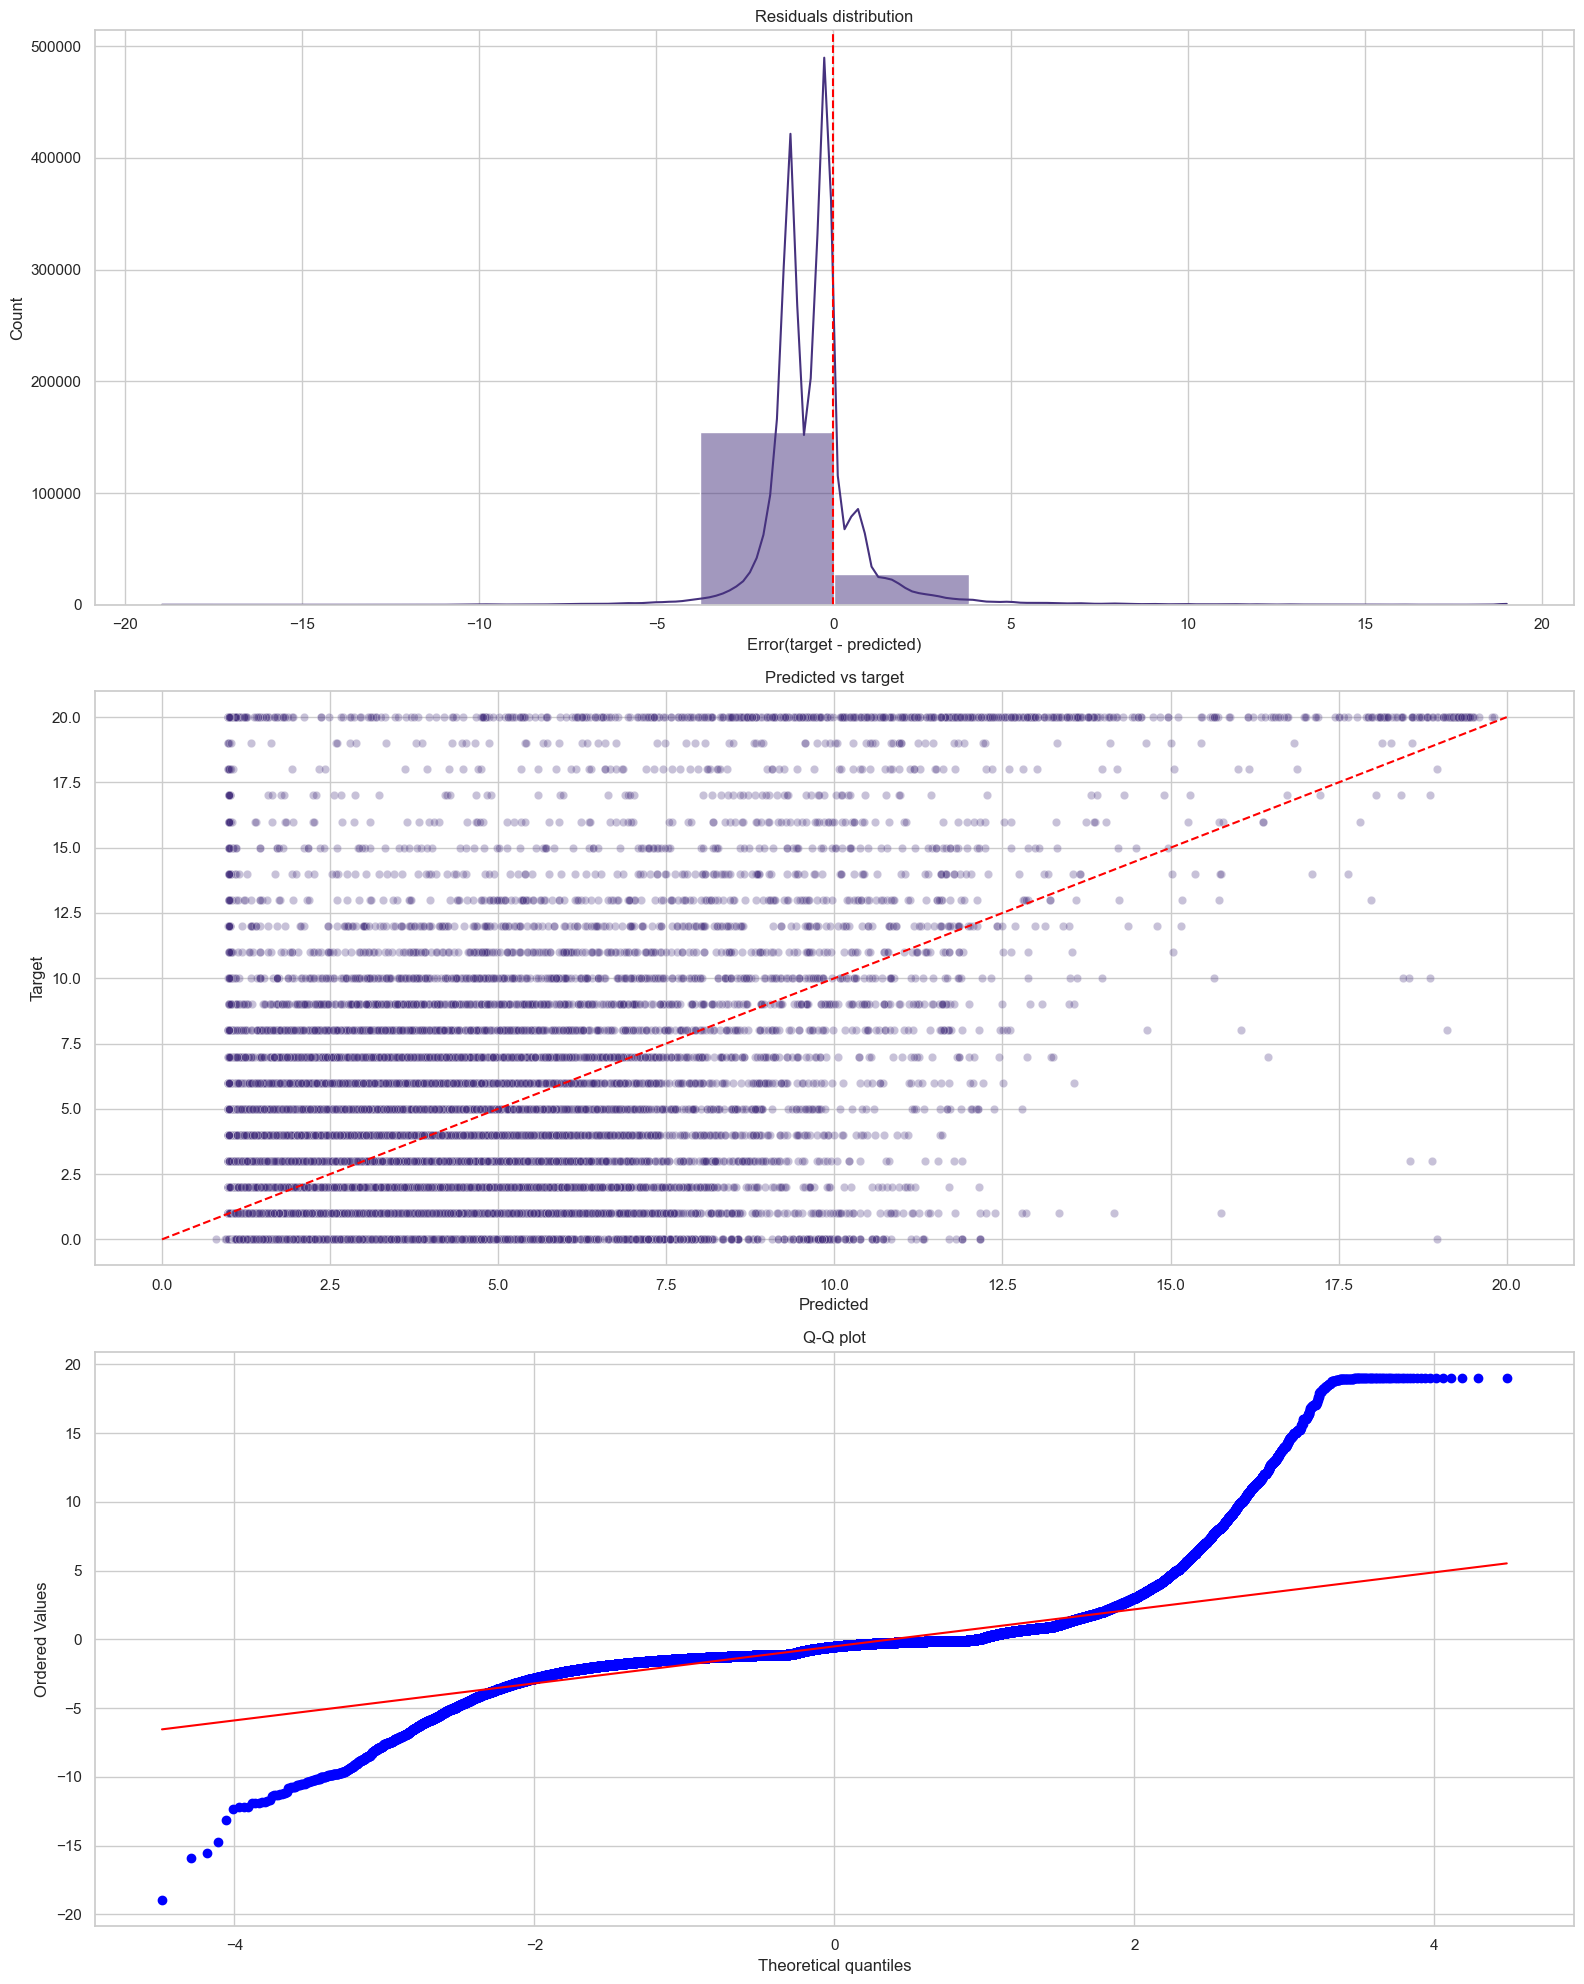

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

sns.histplot(residuals, bins=10, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residuals distribution")
axes[0].set_xlabel("Error(target - predicted)")

sns.scatterplot(x=predict_clipped, y=y_val_array, alpha=0.3, ax=axes[1])
axes[1].plot([0, 20], [0, 20], "r--")
axes[1].set_title("Predicted vs target")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Target")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

In [34]:
print("=" * 50)
print("МЕТРИКИ")
print("=" * 50)
print(f"RMSE: {root_mean_squared_error(y_val_array, predict_clipped):.4f}")
print(f"MAE: {mean_absolute_error(y_val_array, predict_clipped):.4f}")
print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std residual: {residuals.std():.4f}")

МЕТРИКИ
RMSE: 1.6797
MAE: 1.0705
Mean residual: -0.5137
Std residual: 1.5992


In [39]:
error_df = pd.DataFrame(
    {
        "actual": y_val_array,
        "predicted": predict,
        "residual": residuals,
        "abs_error": np.abs(residuals),
        "date_block_num": X_val.date_block_num,
        "shop_id": X_val.shop_id,
        "item_id": X_val.item_id,
    }
)

In [42]:
print("\n" + "=" * 50)
print("ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК")
print("=" * 50)

print(
    error_df.nlargest(10, "abs_error")[
        ["actual", "predicted", "residual", "shop_id", "item_id"]
    ]
)


ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК
         actual  predicted   residual  shop_id  item_id
1786029    20.0   0.986358  19.013642       35    10202
1786028    20.0   0.988015  19.011985       35    10201
1777793    20.0   0.988172  19.011828       35     7223
690732     20.0   0.988786  19.011214       18    10202
1196580    20.0   0.988786  19.011214       26    10202
2417381    20.0   0.990281  19.009719       48    10202
660753     20.0   0.990600  19.009400       18     1583
823311     20.0   0.990600  19.009400       21     7224
943173     20.0   0.990600  19.009400       24     1583
962609     20.0   0.990600  19.009400       24     7223



ТОП-5 МАГАЗИНОВ С САМЫМ БОЛЬШИМ RMSE
         mean_error      rmse  count
shop_id                             
27        -0.227872  1.659192   1189
55        -0.295149  2.357233   2536
47        -0.327277  1.583547   4851
42        -0.364191  1.987753   8830
37        -0.398017  1.494274   3182


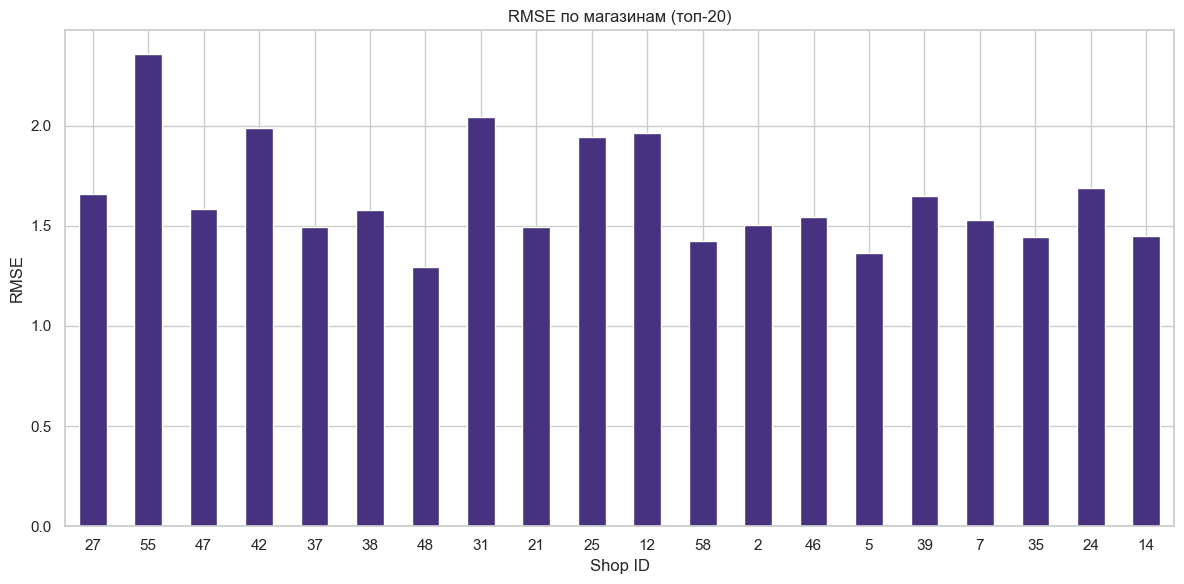

In [43]:
shop_errors = (
    error_df.groupby("shop_id")
    .agg(
        mean_error=("residual", "mean"),
        rmse=("residual", lambda x: np.sqrt((x**2).mean())),
        count=("shop_id", "count"),
    )
    .sort_values("mean_error", ascending=False)
)

print("\n" + "=" * 50)
print("ТОП-5 МАГАЗИНОВ С САМЫМ БОЛЬШИМ RMSE")
print("=" * 50)
print(shop_errors.head(5))

fig, ax = plt.subplots(figsize=(12, 6))
shop_errors.head(20).plot(y="rmse", kind="bar", ax=ax, legend=False)
ax.set_title("RMSE по магазинам (топ-20)")
ax.set_xlabel("Shop ID")
ax.set_ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


ТОП-5 МЕСЯЦЕВ С САМЫМ БОЛЬШИМ RMSE
                mean_error      rmse  count
date_block_num                             
33                0.043001  2.154168  31531
32               -0.567207  1.714596  42334
31               -0.571227  1.524912  52786
30               -0.714550  1.492494  60978


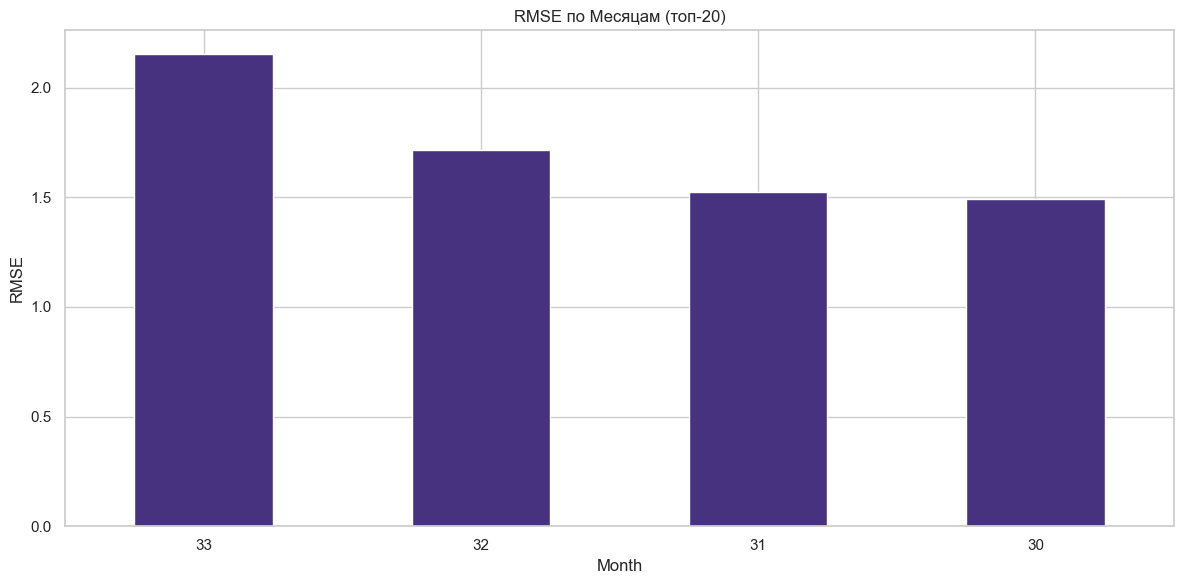

In [44]:
month_errors = (
    error_df.groupby("date_block_num")
    .agg(
        mean_error=("residual", "mean"),
        rmse=("residual", lambda x: np.sqrt((x**2).mean())),
        count=("date_block_num", "count"),
    )
    .sort_values("rmse", ascending=False)
)

print("\n" + "=" * 50)
print("ТОП-5 МЕСЯЦЕВ С САМЫМ БОЛЬШИМ RMSE")
print("=" * 50)
print(month_errors.head(5))

fig, ax = plt.subplots(figsize=(12, 6))
month_errors.head(20).plot(y="rmse", kind="bar", ax=ax, legend=False)
ax.set_title("RMSE по Месяцам (топ-20)")
ax.set_xlabel("Month")
ax.set_ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. АНАЛИЗ ВЫБРОСОВ (САМЫЕ БОЛЬШИЕ ОШИБКИ)

In [ ]:
# Топ-10 худших предсказаний
worst = error_df.nlargest(10, "abs_error").copy()

shops_df = pd.read_csv("data/shops.csv")
items_df = pd.read_csv("data/items.csv")

worst = worst.merge(shops_df[["shop_id", "shop_name"]], on="shop_id", how="left")
worst = worst.merge(items_df[["item_id", "item_name"]], on="item_id", how="left")

print("=" * 50)
print("АНАЛИЗ ХУДШИХ ПРЕДСКАЗАНИЙ")
print("=" * 50)

for i, row in worst.iterrows():
    print(f"\n--- Ошибка #{i + 1} ---")
    print(f"  Товар: {row['item_name'][:50]} (ID: {row['item_id']})")
    print(f"  Магазин: {row['shop_name'][:40]} (ID: {row['shop_id']})")
    print(f"  Месяц: {row['date_block_num']}")
    print(f"  Факт: {row['actual']:.1f} | Предсказано: {row['predicted']:.1f}")
    print(f"  Ошибка: {row['residual']:.1f} (|error|: {row['abs_error']:.1f})")

АНАЛИЗ ХУДШИХ ПРЕДСКАЗАНИЙ

--- Ошибка #1 ---
  Товар: Ведьмак 3: Дикая Охота - Дополнение "Каменные Серд (ID: 10202)
  Магазин: Н.Новгород ТРЦ "Фантастика" (ID: 35)
  Месяц: 33
  Факт: 20.0 | Предсказано: 1.0
  Ошибка: 19.0 (|error|: 19.0)

--- Ошибка #2 ---
  Товар: Ведьмак 3: Дикая Охота - Дополнение "Каменные Серд (ID: 10201)
  Магазин: Н.Новгород ТРЦ "Фантастика" (ID: 35)
  Месяц: 33
  Факт: 20.0 | Предсказано: 1.0
  Ошибка: 19.0 (|error|: 19.0)

--- Ошибка #3 ---
  Товар: Uncharted: Натан Дрейк. Коллекция [PS4, русская ве (ID: 7223)
  Магазин: Н.Новгород ТРЦ "Фантастика" (ID: 35)
  Месяц: 33
  Факт: 20.0 | Предсказано: 1.0
  Ошибка: 19.0 (|error|: 19.0)

--- Ошибка #4 ---
  Товар: Ведьмак 3: Дикая Охота - Дополнение "Каменные Серд (ID: 10202)
  Магазин: Красноярск ТЦ "Июнь" (ID: 18)
  Месяц: 33
  Факт: 20.0 | Предсказано: 1.0
  Ошибка: 19.0 (|error|: 19.0)

--- Ошибка #5 ---
  Товар: Ведьмак 3: Дикая Охота - Дополнение "Каменные Серд (ID: 10202)
  Магазин: Москва ТЦ "Ареал" (Беля

### 6. ПАТТЕРНЫ ОШИБОК: МОДЕЛЬ НЕДООЦЕНИВАЕТ ИЛИ ПЕРЕОЦЕНИВАЕТ?

In [ ]:
print("\n" + "=" * 50)
print("ПАТТЕРНЫ ОШИБОК")
print("=" * 50)

underestimated = error_df[error_df["residual"] > 5]
print(f"\nНедооценка (>5 ед.): {len(underestimated)} примеров")
print(f"  Средний факт: {underestimated['actual'].mean():.1f}")
print(f"  Среднее предсказание: {underestimated['predicted'].mean():.1f}")

overestimated = error_df[error_df["residual"] < -5]
print(f"\nПереоценка (<-5 ед.): {len(overestimated)} примеров")
print(f"  Средний факт: {overestimated['actual'].mean():.1f}")
print(f"  Среднее предсказание: {overestimated['predicted'].mean():.1f}")


ПАТТЕРНЫ ОШИБОК

Недооценка (>5 ед.): 2110 примеров
  Средний факт: 14.0
  Среднее предсказание: 5.1

Переоценка (<-5 ед.): 1054 примеров
  Средний факт: 1.1
  Среднее предсказание: 8.0


### 7. ВЫВОДЫ

In [ ]:
print("\n" + "=" * 50)
print("ВЫВОДЫ ПО АНАЛИЗУ ОШИБОК")
print("=" * 50)

conclusions = [
    f"1. Средняя ошибка (MAE): {mean_absolute_error(y_val_array, predict):.2f}",
    f"2. Модель {'недооценивает' if residuals.mean() > 0 else 'переоценивает'} в среднем на {abs(residuals.mean()):.2f} ед.",
    "3. Основные проблемы: "
    + (
        "выбросы с аномально высокими продажами"
        if len(underestimated) > len(overestimated)
        else "переоценка товаров с низкими продажами"
    ),
    "4. Чего делать?:",
    "   - Отдельный классификатор для высоких продаж (hurdle model)",
    "   - Добавить признак 'волатильность продаж' (std по месяцам)",
    "   - Использовать more robust loss (Huber, Quantile)",
]

for c in conclusions:
    print(c)


ВЫВОДЫ ПО АНАЛИЗУ ОШИБОК
1. Средняя ошибка (MAE): 1.07
2. Модель переоценивает в среднем на 0.51 ед.
3. Основные проблемы: выбросы с аномально высокими продажами
4. Чего делать?:
   - Рассмотреть отдельную модель для высоких продаж (hurdle model)
   - Добавить признак 'волатильность продаж' (std по месяцам)
   - Использовать more robust loss (Huber, Quantile)
